<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/main/XGBoost_Ratio_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, precision_recall_curve, auc)
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

print("🚀 [Step 1 최종 완성판] SMOTE-ENN 정밀 비율 튜닝 (1:7 ~ 1:1) 시작...\n")

# 1. 원본 데이터 로드
try:
    df = pd.read_csv('optimized_data.csv')
    print(f"✅ 데이터 로드 완료: {df.shape}")
except FileNotFoundError:
    print("❌ 'optimized_data.csv' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

X = df.drop(columns=['malware'])
y = df['malware']

# 2. Train / Test 분할 (1:23 실전 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"📊 학습 데이터: {X_train.shape} | 평가 데이터: {X_test.shape} (원본 비율 유지)\n")

results = []

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_0 = recall_score(y_test, y_pred, pos_label=0) # 정상(0) 탐지율
    recall_1 = recall_score(y_test, y_pred, pos_label=1) # 악성(1) 탐지율
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)

    results.append({
        'Model Scenario': name,
        'Accuracy': f"{acc * 100:.2f}%",
        'Precision (Malware)': f"{precision_1 * 100:.2f}%",
        'Recall (Normal: 0)': f"{recall_0 * 100:.2f}%",
        'Recall (Malware: 1)': f"{recall_1 * 100:.2f}%",
        'Macro F1': f"{macro_f1:.4f}",
        'PR-AUC': f"{pr_auc:.4f}"
    })

# ==========================================
# 🛑 1. Baseline (원본 1:23)
# ==========================================
print("[1/8] Baseline (원본 1:23) 학습 중...")
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_base.fit(X_train, y_train)
evaluate_model("Baseline (1:23 Ratio)", xgb_base, X_test, y_test)

# ==========================================
# 튜닝할 타겟 비율 리스트 설정 (1:7 ~ 1:1)
# ==========================================
ratios = {
    "SMOTE-ENN (1:7 Ratio)": 1/7,
    "SMOTE-ENN (1:6 Ratio)": 1/6,
    "SMOTE-ENN (1:5 Ratio)": 1/5,
    "SMOTE-ENN (1:4 Ratio)": 1/4,
    "SMOTE-ENN (1:3 Ratio)": 1/3,
    "SMOTE-ENN (1:2 Ratio)": 1/2,
    "SMOTE-ENN (1:1 Ratio)": 1.0    # 100% 완전 균형
}

step = 2
for name, ratio in ratios.items():
    print(f"[{step}/8] {name} 적용 및 학습 중...")

    # SMOTE-ENN 적용
    smote_enn = SMOTEENN(sampling_strategy=ratio, random_state=42)
    X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

    # XGBoost 학습
    xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
    xgb_model.fit(X_train_res, y_train_res)

    # 평가
    evaluate_model(name, xgb_model, X_test, y_test)
    step += 1

print("\n✅ 모든 벤치마크 완료! 정밀 분석 결과를 출력합니다.\n")

# ==========================================
# 📊 최종 결과 테이블 출력
# ==========================================
results_df = pd.DataFrame(results)
print("-" * 100)
print(results_df.to_string(index=False))
print("-" * 100)

🚀 [Step 1 최종 완성판] SMOTE-ENN 정밀 비율 튜닝 (1:7 ~ 1:1) 시작...

✅ 데이터 로드 완료: (47580, 31)
📊 학습 데이터: (38064, 30) | 평가 데이터: (9516, 30) (원본 비율 유지)

[1/8] Baseline (원본 1:23) 학습 중...
[2/8] SMOTE-ENN (1:7 Ratio) 적용 및 학습 중...
[3/8] SMOTE-ENN (1:6 Ratio) 적용 및 학습 중...
[4/8] SMOTE-ENN (1:5 Ratio) 적용 및 학습 중...
[5/8] SMOTE-ENN (1:4 Ratio) 적용 및 학습 중...
[6/8] SMOTE-ENN (1:3 Ratio) 적용 및 학습 중...
[7/8] SMOTE-ENN (1:2 Ratio) 적용 및 학습 중...
[8/8] SMOTE-ENN (1:1 Ratio) 적용 및 학습 중...

✅ 모든 벤치마크 완료! 정밀 분석 결과를 출력합니다.

----------------------------------------------------------------------------------------------------
       Model Scenario Accuracy Precision (Malware) Recall (Normal: 0) Recall (Malware: 1) Macro F1 PR-AUC
Baseline (1:23 Ratio)   97.77%              97.96%             50.78%              99.76%   0.8188 0.9982
SMOTE-ENN (1:7 Ratio)   97.24%              98.34%             60.62%              98.78%   0.8129 0.9890
SMOTE-ENN (1:6 Ratio)   96.17%              99.14%             80.05%              96.86%   

✅ 전체 스펙트럼 그래프가 'smote_full_spectrum_curve.png'로 저장되었습니다!


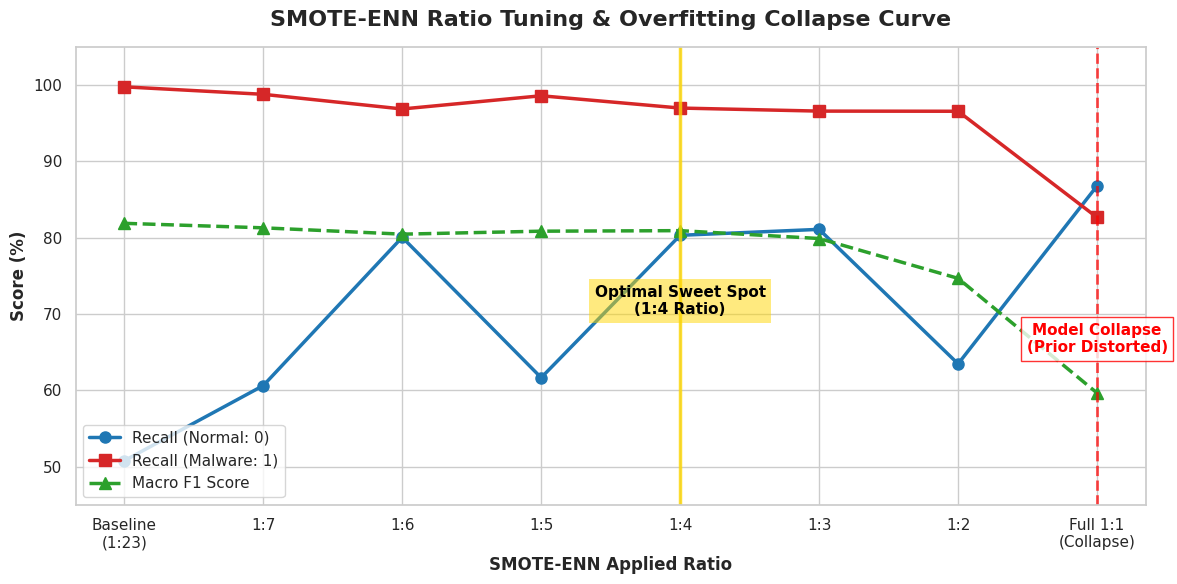

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 방금 뽑아낸 8단계 전체 데이터
scenarios = ['Baseline\n(1:23)', '1:7', '1:6', '1:5', '1:4', '1:3', '1:2', 'Full 1:1\n(Collapse)']
recall_0 = [50.78, 60.62, 80.05, 61.66, 80.31, 81.09, 63.47, 86.79]  # 정상 파일 탐지율
recall_1 = [99.76, 98.78, 96.86, 98.59, 96.98, 96.58, 96.56, 82.65]  # 악성코드 탐지율
macro_f1 = [81.88, 81.29, 80.46, 80.85, 80.92, 79.89, 74.67, 59.65]  # Macro F1 (퍼센트 변환)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. 3개의 선 그래프 그리기
plt.plot(scenarios, recall_0, marker='o', markersize=8, linewidth=2.5, label='Recall (Normal: 0)', color='#1f77b4')
plt.plot(scenarios, recall_1, marker='s', markersize=8, linewidth=2.5, label='Recall (Malware: 1)', color='#d62728')
plt.plot(scenarios, macro_f1, marker='^', markersize=8, linewidth=2.5, linestyle='--', label='Macro F1 Score', color='#2ca02c')

# 3. 1:4 비율 (Sweet Spot) 강조 표시
plt.axvline(x=4, color='gold', linestyle='-', linewidth=2.5, alpha=0.8)
plt.text(4, 70, 'Optimal Sweet Spot\n(1:4 Ratio)', horizontalalignment='center',
         color='black', fontsize=11, fontweight='bold', bbox=dict(facecolor='gold', alpha=0.5, edgecolor='none'))

# 4. 1:1 비율 (Collapse) 강조 표시
plt.axvline(x=7, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(7, 65, 'Model Collapse\n(Prior Distorted)', horizontalalignment='center',
         color='red', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

# 5. 디자인 마무리
plt.title('SMOTE-ENN Ratio Tuning & Overfitting Collapse Curve', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('SMOTE-ENN Applied Ratio', fontsize=12, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.ylim(45, 105)
plt.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig('smote_full_spectrum_curve.png', dpi=300)
print("✅ 전체 스펙트럼 그래프가 'smote_full_spectrum_curve.png'로 저장되었습니다!")
plt.show()